# Benchmark: Screen Diagnostic Methods (Histogram vs. KDE vs. Cloud-in-Cell)
This notebook compares the execution time of the three different image deposition methods supported by the `Screen` diagnostic class:
1. **`'histogram'`**: PyTorch's standard `histogramdd` binning. *Does not support batch vectorization.*
2. **`'kde'`**: Kernel Density Estimation-based smooth distribution tracking.
3. **`'cloud-in-cell'`**: Our optimized Cloud-in-Cell charge deposition method.

We benchmark two scenarios:
- **Non-Vectorized Case (Batch Shape `()`)**: Comparing all three methods.
- **Vectorized Case (Batch Shapes `(20, 1)` and `(2, 10)`)**: Comparing `'kde'` and `'cloud-in-cell'` (since `'histogram'` raises `NotImplementedError` for batches).

In [1]:
import sys
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import platform
import subprocess
import re
import glob

repo_root = os.path.abspath(".")
if repo_root not in sys.path:
    sys.path.append(repo_root)

import cheetah

device_types = ["cpu"]
if torch.cuda.is_available():
    device_types.append("cuda")
if torch.backends.mps.is_available():
    device_types.append("mps")
print(f"Available devices: {device_types}")

def sync(device):
    if device.type == "mps":
        torch.mps.synchronize()
    elif device.type == "cuda":
        torch.cuda.synchronize()

Available devices: ['cpu', 'mps']


In [2]:
def get_cpu_info():
    try:
        if platform.system() == "Windows":
            return platform.processor()
        elif platform.system() == "Darwin":
            return subprocess.check_output(["sysctl", "-n", "machdep.cpu.brand_string"]).decode().strip()
        elif platform.system() == "Linux":
            with open("/proc/cpuinfo", "r") as f:
                for line in f:
                    if "model name" in line:
                        return re.sub(".*model name.*:", "", line, 1).strip()
    except Exception:
        pass
    return platform.processor() or "Unknown CPU"

def get_ram_info():
    try:
        import psutil
        return f"{psutil.virtual_memory().total / (1024**3):.1f} GB"
    except ImportError:
        pass
    try:
        if platform.system() == "Darwin":
            mem_bytes = int(subprocess.check_output(["sysctl", "-n", "hw.memsize"]).decode().strip())
            return f"{mem_bytes / (1024**3):.1f} GB"
        elif platform.system() == "Linux":
            with open("/proc/meminfo", "r") as f:
                for line in f:
                    if "MemTotal" in line:
                        mem_kb = int(line.split()[1])
                        return f"{mem_kb / (1024**2):.1f} GB"
    except Exception:
        pass
    return "Unknown RAM"

def get_gpu_info():
    gpus = []
    if torch.cuda.is_available():
        for i in range(torch.cuda.device_count()):
            gpus.append(torch.cuda.get_device_name(i))
    if torch.backends.mps.is_available():
        gpus.append("Apple Silicon Integrated GPU (MPS)")
    return ", ".join(gpus) if gpus else "None"

cpu_info = get_cpu_info()
ram_info = get_ram_info()
gpu_info = get_gpu_info()
os_info = f"{platform.system()} {platform.release()}"

system_label = f"{os_info} | {cpu_info} | RAM: {ram_info}"
if gpu_info != "None":
    system_label += f" | GPU: {gpu_info}"

print("System Information:")
print(f"OS:  {os_info}")
print(f"CPU: {cpu_info}")
print(f"RAM: {ram_info}")
print(f"GPU: {gpu_info}")
print(f"Label: {system_label}")

System Information:
OS:  Darwin 25.5.0
CPU: Apple M1 Pro
RAM: 32.0 GB
GPU: Apple Silicon Integrated GPU (MPS)
Label: Darwin 25.5.0 | Apple M1 Pro | RAM: 32.0 GB | GPU: Apple Silicon Integrated GPU (MPS)


In [3]:
def run_methods_benchmark(num_runs=10):
    results = []
    H, W = 150, 150
    num_particles = 100000
    
    for device_name in device_types:
        device = torch.device(device_name)
        
        # 1. Non-Vectorized Case (Batch shape = ())
        particles_single = torch.zeros(num_particles, 7, device=device)
        particles_single[:, 0] = torch.randn(num_particles, device=device) * 1e-4
        particles_single[:, 2] = torch.randn(num_particles, device=device) * 1e-4
        beam_single = cheetah.ParticleBeam(
            particles=particles_single,
            energy=torch.tensor(1.0e9, device=device),
            device=device
        )
        
        for method in ["histogram", "kde", "cloud-in-cell"]:
            screen = cheetah.Screen(
                resolution=(W, H),
                pixel_size=torch.tensor((1e-6, 1e-6), device=device),
                is_active=True,
                method=method,
                device=device
            )
            screen.track(beam_single)
            
            # Warmup
            for _ in range(3):
                screen.cached_reading = None
                _ = screen.reading
            sync(device)
            
            t_runs = []
            for _ in range(num_runs):
                t0 = time.perf_counter()
                screen.cached_reading = None
                _ = screen.reading
                sync(device)
                t_runs.append(time.perf_counter() - t0)
                
            results.append({
                "Device": device_name.upper(),
                "Batch Shape": "()",
                "Method": method,
                "Time (s)": np.mean(t_runs)
            })
            
        # 2. Vectorized Cases
        batch_shapes = [(20, 1), (2, 10)]
        for batch_shape in batch_shapes:
            particles_batched = torch.zeros(*batch_shape, num_particles, 7, device=device)
            particles_batched[..., 0] = torch.randn(*batch_shape, num_particles, device=device) * 1e-4
            particles_batched[..., 2] = torch.randn(*batch_shape, num_particles, device=device) * 1e-4
            beam_batched = cheetah.ParticleBeam(
                particles=particles_batched,
                energy=torch.tensor(1.0e9, device=device),
                device=device
            )
            
            for method in ["kde", "cloud-in-cell"]:
                screen = cheetah.Screen(
                    resolution=(W, H),
                    pixel_size=torch.tensor((1e-6, 1e-6), device=device),
                    is_active=True,
                    method=method,
                    device=device
                )
                screen.track(beam_batched)
                
                # Warmup
                for _ in range(3):
                    screen.cached_reading = None
                    _ = screen.reading
                sync(device)
                
                t_runs = []
                for _ in range(num_runs):
                    t0 = time.perf_counter()
                    screen.cached_reading = None
                    _ = screen.reading
                    sync(device)
                    t_runs.append(time.perf_counter() - t0)
                    
                results.append({
                    "Device": device_name.upper(),
                    "Batch Shape": str(batch_shape),
                    "Method": method,
                    "Time (s)": np.mean(t_runs)
                })
                
    df = pd.DataFrame(results)
    return df

df_methods = run_methods_benchmark()
df_methods

,Device,Batch Shape,Method,Time (s)
0,CPU,(),histogram,0.000948
1,CPU,(),kde,0.065662
2,CPU,(),cloud-in-cell,0.006510
3,CPU,"(20, 1)",kde,1.396970
4,CPU,"(20, 1)",cloud-in-cell,0.040253
5,CPU,"(2, 10)",kde,1.308898
6,CPU,"(2, 10)",cloud-in-cell,0.043397
7,MPS,(),histogram,0.786048
8,MPS,(),kde,0.035149
9,MPS,(),cloud-in-cell,0.004118


In [4]:
# Save results
run_data = []
for idx, row in df_methods.iterrows():
    run_data.append({
        "System": system_label,
        "Device": row["Device"],
        "Batch Shape": row["Batch Shape"],
        "Method": row["Method"],
        "Time (s)": row["Time (s)"]
    })
df_run = pd.DataFrame(run_data)

system_slug = re.sub(r'[^a-z0-9]+', '_', system_label.lower()).strip('_')
results_dir = os.path.join(repo_root, "dev", "benchmark_results")
os.makedirs(results_dir, exist_ok=True)
csv_filename = os.path.join(results_dir, f"methods_results_{system_slug}.csv")
df_run.to_csv(csv_filename, index=False)
print(f"Saved current run results to {csv_filename}")

# Load all methods results
all_files = glob.glob(os.path.join(results_dir, "methods_results_*.csv"))
print(f"Found {len(all_files)} methods results files:")
all_dfs = []
for file in all_files:
    print(f" - {os.path.basename(file)}")
    all_dfs.append(pd.read_csv(file))
combined_df = pd.concat(all_dfs, ignore_index=True)
combined_df

Saved current run results to /Users/jankaiser/Documents/DESY/cheetah/dev/benchmark_results/methods_results_darwin_25_5_0_apple_m1_pro_ram_32_0_gb_gpu_apple_silicon_integrated_gpu_mps.csv
Found 2 methods results files:
 - methods_results_linux_5_14_0_687_13_1_el9_8_x86_64_amd_epyc_7513_32_core_processor_ram_503_2_gb_gpu_nvidia_a100_80gb_pcie.csv
 - methods_results_darwin_25_5_0_apple_m1_pro_ram_32_0_gb_gpu_apple_silicon_integrated_gpu_mps.csv


,System,Device,Batch Shape,Method,Time (s)
0,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CPU,(),kde,0.094851
1,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CPU,(),cloud-in-cell,0.004467
2,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CPU,"(20, 1)",kde,0.912996
3,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CPU,"(20, 1)",cloud-in-cell,0.019523
4,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CPU,"(2, 10)",kde,0.811198
5,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CPU,"(2, 10)",cloud-in-cell,0.018633
6,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CUDA,(),kde,0.003262
7,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CUDA,(),cloud-in-cell,0.001058
8,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CUDA,"(20, 1)",kde,0.045516
9,Linux 5.14.0-687.13.1.el9_8.x86_64 | AMD EPYC ...,CUDA,"(20, 1)",cloud-in-cell,0.001820


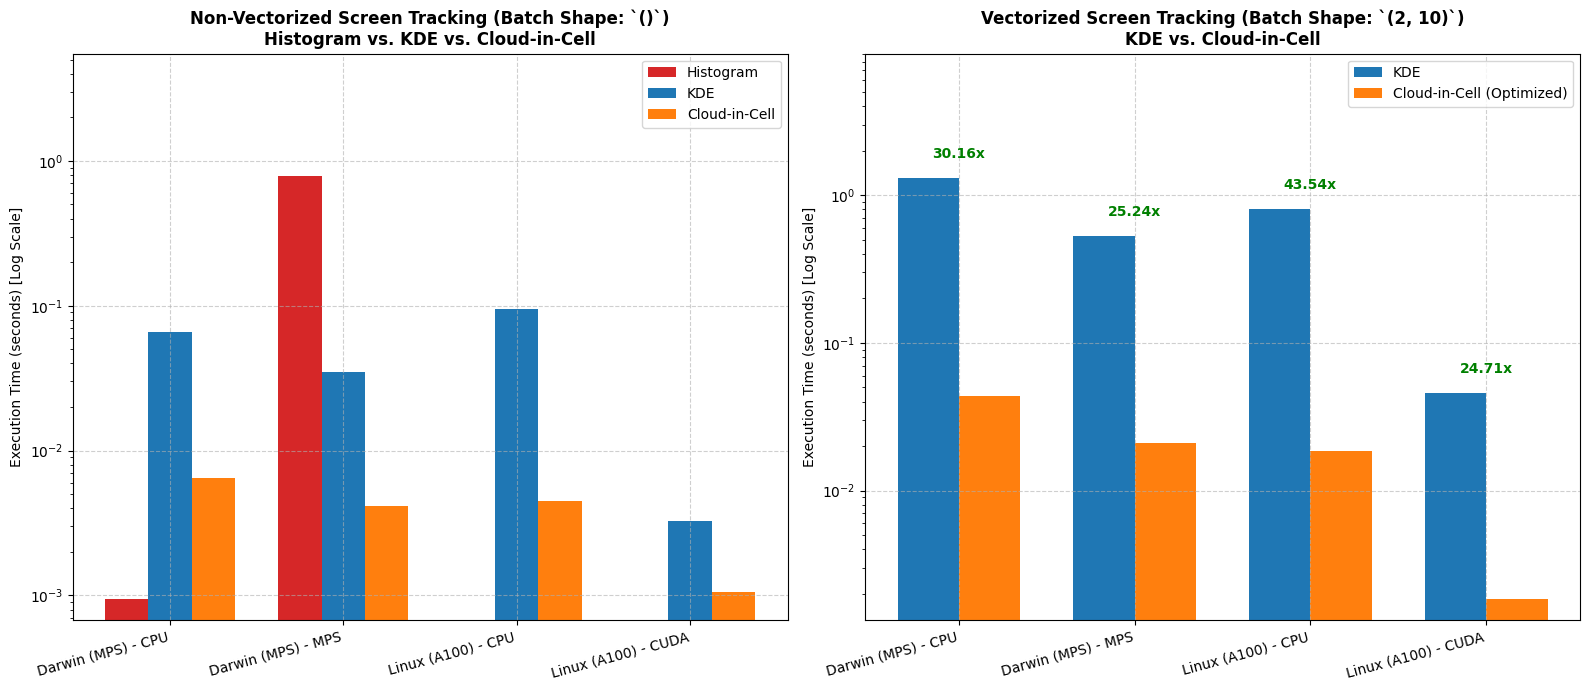

In [5]:
def plot_methods_comparison(df):
    # Filter configs
    configs = []
    for idx, row in df.iterrows():
        sys_name = row["System"]
        device = row["Device"]
        os_name = sys_name.split("|")[0].strip().split()[0]
        
        gpu_part = ""
        if "GPU:" in sys_name:
            gpu_name = sys_name.split("GPU:")[-1].strip()
            if "A100" in gpu_name:
                gpu_part = " (A100)"
            elif "MPS" in gpu_name:
                gpu_part = " (MPS)"
        
        label = f"{os_name}{gpu_part} - {device}"
        configs.append((sys_name, device, label))
        
    configs = list(set(configs))
    configs.sort(key=lambda x: x[2])
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Subplot 1: Non-Vectorized Case (Batch Shape = ())
    ax1 = axes[0]
    df_single = df[df["Batch Shape"] == "()"]
    
    x_labels = [c[2] for c in configs]
    x = np.arange(len(x_labels))
    width = 0.25
    
    methods = ["histogram", "kde", "cloud-in-cell"]
    colors = {"histogram": "#d62728", "kde": "#1f77b4", "cloud-in-cell": "#ff7f0e"}
    method_labels = {"histogram": "Histogram", "kde": "KDE", "cloud-in-cell": "Cloud-in-Cell"}
    
    for offset_idx, method in enumerate(methods):
        times = []
        for sys_name, dev, _ in configs:
            sub = df_single[(df_single["System"] == sys_name) & (df_single["Device"] == dev) & (df_single["Method"] == method)]
            times.append(sub["Time (s)"].iloc[0] if not sub.empty else 0.0)
        
        ax1.bar(x + (offset_idx - 1) * width, times, width, label=method_labels[method], color=colors[method])
        
    ax1.set_title("Non-Vectorized Screen Tracking (Batch Shape: `()`)\nHistogram vs. KDE vs. Cloud-in-Cell", fontsize=12, fontweight="bold")
    ax1.set_xticks(x)
    ax1.set_xticklabels(x_labels, rotation=15, ha="right")
    ax1.set_ylabel("Execution Time (seconds) [Log Scale]")
    ax1.set_yscale("log")
    ax1.legend()
    ax1.grid(True, linestyle="--", alpha=0.6)
    
    # Subplot 2: Vectorized Case (Comparing KDE vs Cloud-in-Cell for shape (2, 10))
    ax2 = axes[1]
    df_vector = df[df["Batch Shape"] == "(2, 10)"]
    
    # Format x-labels for shape (2, 10)
    x_labels_vec = []
    kde_times = []
    cic_times = []
    
    for sys_name, dev, label in configs:
        sub_kde = df_vector[(df_vector["System"] == sys_name) & (df_vector["Device"] == dev) & (df_vector["Method"] == "kde")]
        sub_cic = df_vector[(df_vector["System"] == sys_name) & (df_vector["Device"] == dev) & (df_vector["Method"] == "cloud-in-cell")]
        
        if not sub_kde.empty and not sub_cic.empty:
            x_labels_vec.append(label)
            kde_times.append(sub_kde["Time (s)"].iloc[0])
            cic_times.append(sub_cic["Time (s)"].iloc[0])
            
    x_vec = np.arange(len(x_labels_vec))
    width_vec = 0.35
    
    rects1 = ax2.bar(x_vec - width_vec/2, kde_times, width_vec, label="KDE", color="#1f77b4")
    rects2 = ax2.bar(x_vec + width_vec/2, cic_times, width_vec, label="Cloud-in-Cell (Optimized)", color="#ff7f0e")
    
    ax2.set_title("Vectorized Screen Tracking (Batch Shape: `(2, 10)`)\nKDE vs. Cloud-in-Cell", fontsize=12, fontweight="bold")
    ax2.set_xticks(x_vec)
    ax2.set_xticklabels(x_labels_vec, rotation=15, ha="right")
    ax2.set_ylabel("Execution Time (seconds) [Log Scale]")
    ax2.set_yscale("log")
    ax2.legend()
    ax2.grid(True, linestyle="--", alpha=0.6)
    
    # Add speedup labels for Cloud-in-Cell over KDE
    for i in range(len(x_labels_vec)):
        speedup = kde_times[i] / cic_times[i]
        max_val = max(kde_times[i], cic_times[i])
        ax2.text(i, max_val * 1.3, f"{speedup:.2f}x", ha="center", va="bottom", color="green", fontweight="bold")
        
    # Adjust y-limits to make room for labels
    _, y_max1 = ax1.get_ylim()
    ax1.set_ylim(top=y_max1 * 5.0)
    _, y_max2 = ax2.get_ylim()
    ax2.set_ylim(top=y_max2 * 5.0)
    
    plt.tight_layout()
    plt.savefig("screen_methods_comparison.png", dpi=300)
    plt.show()

plot_methods_comparison(combined_df)